In [ ]:
import pandas as pd                                                                                                                                                     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/pcos_data_veryfinal.csv.xlsx')

In [ ]:
print(df.shape)

(541, 45)


In [ ]:
print(df.dtypes)

Sl. No                    int64
PCOS (Y/N)                int64
 Age (yrs)                int64
Weight (Kg)             float64
Height(Cm)              float64
Cycle(R/I)                int64
Cycle length(days)        int64
Hip(inch)                 int64
Waist(inch)               int64
Waist:Hip Ratio         float64
Weight gain(Y/N)          int64
hair growth(Y/N)          int64
Skin darkening (Y/N)      int64
Hair loss(Y/N)            int64
Pimples(Y/N)              int64
Fast food (Y/N)         float64
Reg.Exercise(Y/N)         int64
Unnamed: 17             float64
Unnamed: 18             float64
Unnamed: 19             float64
Unnamed: 20             float64
Unnamed: 21             float64
Unnamed: 22             float64
Unnamed: 23             float64
Unnamed: 24             float64
Unnamed: 25             float64
Unnamed: 26             float64
Unnamed: 27             float64
Unnamed: 28             float64
Unnamed: 29             float64
Unnamed: 30             float64
Unnamed:

In [ ]:
for col in df.columns:
    print(col, df[col].unique())


Sl. No [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245

In [ ]:
print(df.isnull().sum())

Sl. No                    0
PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
Cycle(R/I)                0
Cycle length(days)        0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)           1
Reg.Exercise(Y/N)         0
Unnamed: 17             541
Unnamed: 18             541
Unnamed: 19             541
Unnamed: 20             541
Unnamed: 21             541
Unnamed: 22             541
Unnamed: 23             541
Unnamed: 24             541
Unnamed: 25             541
Unnamed: 26             541
Unnamed: 27             541
Unnamed: 28             541
Unnamed: 29             541
Unnamed: 30             541
Unnamed: 31             541
Unnamed: 32             541
Unnamed: 33             541
Unnamed: 34             541
Unnamed: 35         

In [ ]:
df = df.drop(columns=['Sl. No'])

In [ ]:
df['Fast food (Y/N)'].fillna(df['Fast food (Y/N)'].mode()[0], inplace=True) #AS THERE IS ONE MISSING VALUE


In [ ]:
df['Cycle(R/I)'].replace(5, df['Cycle(R/I)'].mode()[0], inplace=True)
df['Cycle(R/I)'] = df['Cycle(R/I)'].map({2:0, 4:1})

In [ ]:
import numpy as np
df = df.replace('.', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.median(), inplace=True)


In [ ]:
print(df.isnull().sum())

PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
Cycle(R/I)                0
Cycle length(days)        0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)           0
Reg.Exercise(Y/N)         0
Unnamed: 17             541
Unnamed: 18             541
Unnamed: 19             541
Unnamed: 20             541
Unnamed: 21             541
Unnamed: 22             541
Unnamed: 23             541
Unnamed: 24             541
Unnamed: 25             541
Unnamed: 26             541
Unnamed: 27             541
Unnamed: 28             541
Unnamed: 29             541
Unnamed: 30             541
Unnamed: 31             541
Unnamed: 32             541
Unnamed: 33             541
Unnamed: 34             541
Unnamed: 35             541
Unnamed: 36         

BASELINE MODEL - LOGISTIC REGRESSION

In [ ]:
X = df.drop('PCOS (Y/N)', axis=1)
y = df['PCOS (Y/N)']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
print(X_train.isnull().sum())

 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
Cycle(R/I)                0
Cycle length(days)        0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)           0
Reg.Exercise(Y/N)         0
Unnamed: 17             432
Unnamed: 18             432
Unnamed: 19             432
Unnamed: 20             432
Unnamed: 21             432
Unnamed: 22             432
Unnamed: 23             432
Unnamed: 24             432
Unnamed: 25             432
Unnamed: 26             432
Unnamed: 27             432
Unnamed: 28             432
Unnamed: 29             432
Unnamed: 30             432
Unnamed: 31             432
Unnamed: 32             432
Unnamed: 33             432
Unnamed: 34             432
Unnamed: 35             432
Unnamed: 36             432
Unnamed: 37         

In [ ]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [ ]:
print(df.isnull().sum())

PCOS (Y/N)              0
 Age (yrs)              0
Weight (Kg)             0
Height(Cm)              0
Cycle(R/I)              0
Cycle length(days)      0
Hip(inch)               0
Waist(inch)             0
Waist:Hip Ratio         0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         0
Reg.Exercise(Y/N)       0
dtype: int64


In [ ]:
import numpy as np
print(np.isnan(X_train_scaled).sum())

11664


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Identify columns in X_train that are entirely NaN
nan_cols_indices = np.where(X_train.isnull().all())[0]

# Remove these NaN columns from the scaled data
X_train_scaled_cleaned = np.delete(X_train_scaled, nan_cols_indices, axis=1)
X_test_scaled_cleaned = np.delete(X_test_scaled, nan_cols_indices, axis=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled_cleaned, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  #EVALUATION

y_pred = model.predict(X_test_scaled_cleaned)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8807339449541285

Confusion Matrix:
 [[72  5]
 [ 8 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92        77
           1       0.83      0.75      0.79        32

    accuracy                           0.88       109
   macro avg       0.86      0.84      0.85       109
weighted avg       0.88      0.88      0.88       109



GAN MODEL - CREATING SYNTHESISED DATA


In [ ]:
!pip install sdv

In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

In [ ]:
categorical_columns = [
    'PCOS (Y/N)',
    'Cycle(R/I)',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)',
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)'
]

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

for col in categorical_columns:
    metadata.update_column(
        column_name=col,
        sdtype='categorical'
    )



In [ ]:
ctgan = CTGANSynthesizer(metadata, epochs=300)

ctgan.fit(df)

In [ ]:
synthetic_data = ctgan.sample(4500)

print(synthetic_data.shape)

(4500, 16)


VALIDATION OF SYNTHETIC DATA


*  MEAN AND STD DEVIATION




In [ ]:
print("Original shape:", df.shape)
print("Synthetic shape:", synthetic_data.shape)

Original shape: (541, 16)
Synthetic shape: (4500, 16)


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Original Mean": df.mean(),
    "Synthetic Mean": synthetic_data.mean(),
    "Original Std": df.std(),
    "Synthetic Std": synthetic_data.std()
})

print(comparison)


                      Original Mean  Synthetic Mean  Original Std  \
PCOS (Y/N)                 0.327172        0.325556      0.469615   
 Age (yrs)                31.430684       31.590667      5.411006   
Weight (Kg)               59.637153       65.014444     11.028287   
Height(Cm)               156.484835      154.863877      6.033545   
Cycle(R/I)                 0.277264        0.366000      0.448062   
Cycle length(days)         4.940850        4.705556      1.492020   
Hip(inch)                 37.992606       38.786000      3.967920   
Waist(inch)               33.841035       33.531778      3.596894   
Waist:Hip Ratio            0.891627        0.865924      0.046135   
Weight gain(Y/N)           0.377079        0.478667      0.485104   
hair growth(Y/N)           0.273567        0.339111      0.446202   
Skin darkening (Y/N)       0.306839        0.293333      0.461609   
Hair loss(Y/N)             0.452865        0.426444      0.498234   
Pimples(Y/N)               0.48983

In [ ]:
print(df['PCOS (Y/N)'].value_counts(normalize=True))

PCOS (Y/N)
0    0.672828
1    0.327172
Name: proportion, dtype: float64


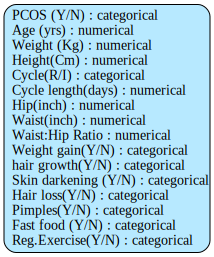

In [ ]:
metadata.visualize()

In [ ]:
from sdv.single_table import CTGANSynthesizer

ctgan = CTGANSynthesizer(
    metadata,
    epochs=800,
    batch_size=50,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    verbose=True
)

ctgan.fit(df)

Gen. (-02.19) | Discrim. (-00.58): 100%|██████████| 800/800 [04:04<00:00,  3.27it/s]


In [ ]:
synthetic_data = ctgan.sample(4500)

print(synthetic_data.shape)

(4500, 16)


In [ ]:
comparison = pd.DataFrame({
    "Original Mean": df.mean(),
    "Synthetic Mean": synthetic_data.mean(),
    "Original Std": df.std(),
    "Synthetic Std": synthetic_data.std()
})

print(comparison)

                      Original Mean  Synthetic Mean  Original Std  \
PCOS (Y/N)                 0.327172        0.384000      0.469615   
 Age (yrs)                31.430684       31.480444      5.411006   
Weight (Kg)               59.637153       63.729867     11.028287   
Height(Cm)               156.484835      157.513942      6.033545   
Cycle(R/I)                 0.277264        0.303111      0.448062   
Cycle length(days)         4.940850        5.216000      1.492020   
Hip(inch)                 37.992606       40.593333      3.967920   
Waist(inch)               33.841035       34.501778      3.596894   
Waist:Hip Ratio            0.891627        0.877247      0.046135   
Weight gain(Y/N)           0.377079        0.362222      0.485104   
hair growth(Y/N)           0.273567        0.233333      0.446202   
Skin darkening (Y/N)       0.306839        0.396222      0.461609   
Hair loss(Y/N)             0.452865        0.483333      0.498234   
Pimples(Y/N)               0.48983

In [ ]:
from sdv.sampling import Condition
import pandas as pd

condition_0 = Condition(
    num_rows=3000,
    column_values={'PCOS (Y/N)': 0}
)

condition_1 = Condition(
    num_rows=1500,
    column_values={'PCOS (Y/N)': 1}
)

synthetic_data = ctgan.sample_from_conditions(
    conditions=[condition_0, condition_1]
)

print(synthetic_data.shape)

Sampling conditions: 100%|██████████| 4500/4500 [00:01<00:00, 3335.21it/s]

(4500, 16)


In [ ]:
print(synthetic_data['PCOS (Y/N)'].value_counts(normalize=True))

PCOS (Y/N)
0    0.666667
1    0.333333
Name: proportion, dtype: float64


In [ ]:
comparison = pd.DataFrame({
    "Original Mean": df.mean(),
    "Synthetic Mean": synthetic_data.mean(),
    "Original Std": df.std(),
    "Synthetic Std": synthetic_data.std()
})

print(comparison)

                      Original Mean  Synthetic Mean  Original Std  \
PCOS (Y/N)                 0.327172        0.333333      0.469615   
 Age (yrs)                31.430684       31.627556      5.411006   
Weight (Kg)               59.637153       62.831333     11.028287   
Height(Cm)               156.484835      157.423494      6.033545   
Cycle(R/I)                 0.277264        0.281556      0.448062   
Cycle length(days)         4.940850        5.244667      1.492020   
Hip(inch)                 37.992606       40.598000      3.967920   
Waist(inch)               33.841035       34.401333      3.596894   
Waist:Hip Ratio            0.891627        0.878596      0.046135   
Weight gain(Y/N)           0.377079        0.331111      0.485104   
hair growth(Y/N)           0.273567        0.211556      0.446202   
Skin darkening (Y/N)       0.306839        0.375556      0.461609   
Hair loss(Y/N)             0.452865        0.467333      0.498234   
Pimples(Y/N)               0.48983



*   KS TEST



In [ ]:
from scipy.stats import ks_2samp
import pandas as pd

In [ ]:
print(df.columns.tolist())

['PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'Cycle(R/I)', 'Cycle length(days)', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']


In [ ]:
print(df.columns.tolist())

['PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'Cycle(R/I)', 'Cycle length(days)', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']


In [ ]:
print(synthetic_data.columns.tolist())

['PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'Cycle(R/I)', 'Cycle length(days)', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']


In [ ]:
df.columns = df.columns.str.strip()
synthetic_data.columns = synthetic_data.columns.str.strip()

In [ ]:
continuous_cols = [
    'Age (yrs)',
    'Weight (Kg)',
    'Height(Cm)',
    'Cycle length(days)',
    'Hip(inch)',
    'Waist(inch)',
    'Waist:Hip Ratio'
]

In [ ]:
ks_results = []

for col in continuous_cols:
    stat, p_value = ks_2samp(df[col], synthetic_data[col])
    ks_results.append({
        'Feature': col,
        'KS Statistic': stat,
        'p-value': p_value
    })

ks_df = pd.DataFrame(ks_results)
print(ks_df)

              Feature  KS Statistic       p-value
0           Age (yrs)      0.085418  1.622191e-03
1         Weight (Kg)      0.179189  4.931119e-14
2          Height(Cm)      0.108803  1.954005e-05
3  Cycle length(days)      0.077077  6.061987e-03
4           Hip(inch)      0.318922  4.310269e-44
5         Waist(inch)      0.101824  8.170719e-05
6     Waist:Hip Ratio      0.169534  1.335151e-12


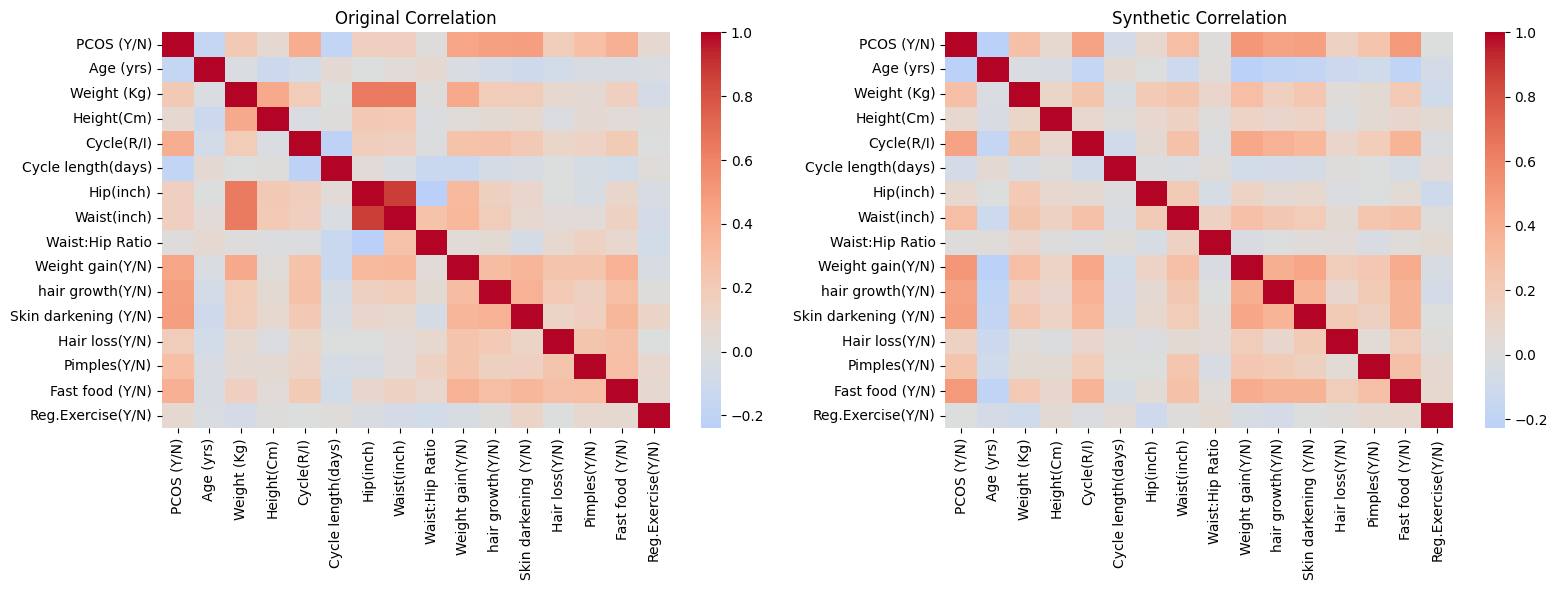

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure same column order
synthetic_data = synthetic_data[df.columns]

# Compute correlations
corr_real = df.corr()
corr_synth = synthetic_data.corr()

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(corr_real, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title("Original Correlation")

sns.heatmap(corr_synth, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title("Synthetic Correlation")

plt.tight_layout()
plt.show()


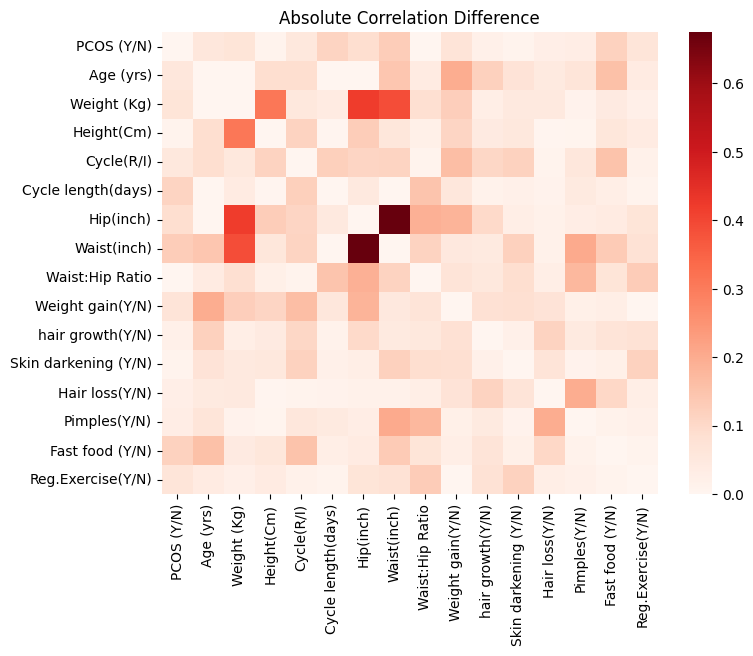

Average Correlation Difference: 0.07429964472654503


In [ ]:
corr_diff = abs(corr_real - corr_synth)

plt.figure(figsize=(8,6))
sns.heatmap(corr_diff, cmap='Reds')
plt.title("Absolute Correlation Difference")
plt.show()

# Optional: Print average difference
print("Average Correlation Difference:",
      corr_diff.values.mean())



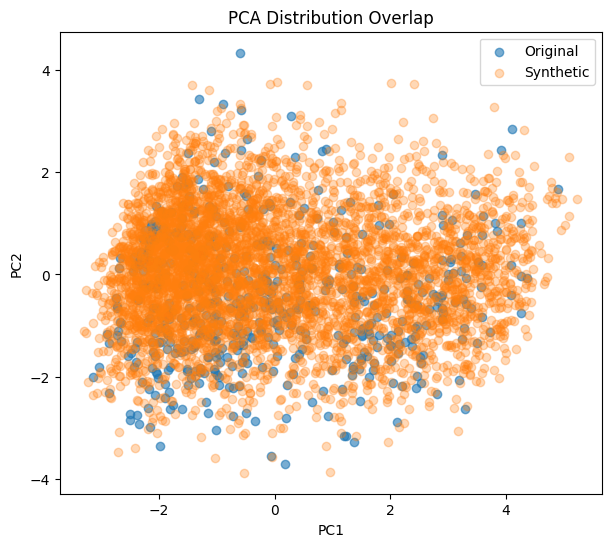

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Combine datasets
combined = pd.concat([df, synthetic_data], axis=0)

# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(combined)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

# Split back
real_pca = pca_result[:len(df)]
synth_pca = pca_result[len(df):]

# Plot
plt.figure(figsize=(7,6))
plt.scatter(real_pca[:,0], real_pca[:,1],
            alpha=0.6, label='Original')
plt.scatter(synth_pca[:,0], synth_pca[:,1],
            alpha=0.3, label='Synthetic')

plt.legend()
plt.title("PCA Distribution Overlap")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"]

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
X_train_real.columns = X_train_real.columns.str.strip()

In [ ]:
print(df.columns.tolist())

['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Cycle(R/I)', 'Cycle length(days)', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print(df.columns.tolist())



['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Cycle(R/I)', 'Cycle length(days)', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']


In [ ]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

In [ ]:
df.columns = df.columns.str.strip()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

In [ ]:
print(df.columns.tolist())

['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Cycle(R/I)', 'Cycle length(days)', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"]

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_real = pd.concat([X_train_real, y_train_real], axis=1)

In [ ]:
from sdv.single_table import CTGANSynthesizer

ctgan = CTGANSynthesizer(
    metadata,
    epochs=800,
    batch_size=64,
    pac=1,          # ← IMPORTANT FIX
    verbose=True
)

In [ ]:
ctgan.fit(train_real)

Gen. (-00.86) | Discrim. (-00.28): 100%|██████████| 800/800 [02:19<00:00,  5.73it/s]


In [ ]:
synthetic_train = ctgan.sample(len(train_real))

In [ ]:
train_real = pd.concat([X_train_real, y_train_real], axis=1)

In [ ]:
augmented_train = pd.concat([train_real, synthetic_train], axis=0).reset_index(drop=True)

In [ ]:
X_train_aug = augmented_train.drop("PCOS (Y/N)", axis=1)
y_train_aug = augmented_train["PCOS (Y/N)"]

In [ ]:
print(augmented_train["PCOS (Y/N)"].isna().sum())

0


In [ ]:
augmented_train = augmented_train.dropna(subset=["PCOS (Y/N)"]).reset_index(drop=True)

In [ ]:
X_train_aug = augmented_train.drop("PCOS (Y/N)", axis=1)
y_train_aug = augmented_train["PCOS (Y/N)"]


In [ ]:
y_train_aug = y_train_aug.astype(int)

In [ ]:
model.fit(X_train_aug, y_train_aug)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

baseline_model.fit(X_train_real, y_train_real)

y_pred_base = baseline_model.predict(X_test_real)
y_prob_base = baseline_model.predict_proba(X_test_real)[:, 1]

print("BASELINE RESULTS")
print(classification_report(y_test_real, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test_real, y_prob_base))


BASELINE RESULTS
              precision    recall  f1-score   support

           0       0.81      0.93      0.87        73
           1       0.80      0.56      0.66        36

    accuracy                           0.81       109
   macro avg       0.80      0.74      0.76       109
weighted avg       0.81      0.81      0.80       109

ROC-AUC: 0.8970700152207003


In [ ]:
aug_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

aug_model.fit(X_train_aug, y_train_aug)

y_pred_aug = aug_model.predict(X_test_real)
y_prob_aug = aug_model.predict_proba(X_test_real)[:, 1]

print("AUGMENTED RESULTS")
print(classification_report(y_test_real, y_pred_aug))
print("ROC-AUC:", roc_auc_score(y_test_real, y_prob_aug))


AUGMENTED RESULTS
              precision    recall  f1-score   support

           0       0.85      0.90      0.87        73
           1       0.77      0.67      0.72        36

    accuracy                           0.83       109
   macro avg       0.81      0.79      0.80       109
weighted avg       0.82      0.83      0.82       109

ROC-AUC: 0.8824200913242009


In [ ]:
synthetic_full = ctgan.sample(4500)

In [ ]:
synthetic_full = synthetic_full.dropna(subset=["PCOS (Y/N)"]).reset_index(drop=True)
synthetic_full["PCOS (Y/N)"] = synthetic_full["PCOS (Y/N)"].astype(int)

In [ ]:
print(df.shape)

(541, 16)


In [ ]:
print(synthetic_full.shape)

(4500, 16)


In [ ]:
full_augmented_dataset = pd.concat([df, synthetic_full], axis=0).reset_index(drop=True)

print("Final shape:", full_augmented_dataset.shape)

Final shape: (5041, 16)


In [ ]:
full_augmented_dataset.head()


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Cycle(R/I),Cycle length(days),Hip(inch),Waist(inch),Waist:Hip Ratio,Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
0,0,28,44.6,152.0,0,5,36,30,0.83,0,0,0,0,0,1.0,0
1,0,36,65.0,161.5,0,5,38,32,0.84,0,0,0,0,0,0.0,0
2,1,33,68.8,165.0,0,5,40,36,0.90,0,0,0,1,1,1.0,0
3,0,37,65.0,148.0,0,5,42,36,0.86,0,0,0,0,0,0.0,0
4,0,25,52.0,161.0,0,5,37,30,0.81,0,0,0,1,0,0.0,0


In [ ]:
full_augmented_dataset.tail()

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Cycle(R/I),Cycle length(days),Hip(inch),Waist(inch),Waist:Hip Ratio,Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
5036,0,39,31.0,147.162,0,6,35,31,0.87,0,0,0,0,0,1.0,0
5037,0,39,34.5,150.001,0,5,26,28,0.92,0,0,0,1,1,0.0,0
5038,1,27,40.7,150.560,0,5,32,25,0.82,1,1,0,0,1,1.0,0
5039,0,41,50.4,148.544,0,4,37,29,0.95,0,0,0,0,0,1.0,0
5040,1,33,49.2,159.904,0,5,37,32,0.92,0,0,1,0,1,1.0,0


In [ ]:
full_augmented_dataset.sample(10)

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Cycle(R/I),Cycle length(days),Hip(inch),Waist(inch),Waist:Hip Ratio,Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
2993,0,35,53.1,148.991,1,4,39,28,0.89,1,0,0,1,0,1.0,1
3209,1,36,66.6,154.358,1,3,44,43,0.93,1,1,0,1,1,1.0,0
4461,0,30,48.2,153.961,0,5,35,25,0.85,0,0,0,0,0,0.0,0
3697,0,36,59.3,148.631,1,4,41,32,0.95,1,0,1,1,0,1.0,0
4352,1,29,43.9,155.378,0,5,34,32,0.93,0,1,0,1,1,1.0,0
876,0,31,50.4,152.945,1,8,46,44,0.91,0,0,0,0,0,0.0,0
1370,0,34,66.7,146.008,0,5,44,35,0.87,0,0,0,0,1,1.0,1
3871,0,39,35.1,146.605,0,5,36,32,0.92,0,0,0,0,0,0.0,0
237,1,25,42.0,154.000,1,3,33,30,0.91,1,0,0,1,1,0.0,0
1710,0,36,42.4,150.616,0,5,33,30,0.91,0,0,0,0,0,0.0,0


In [ ]:
full_augmented_dataset

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Cycle(R/I),Cycle length(days),Hip(inch),Waist(inch),Waist:Hip Ratio,Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
0,0,28,44.6,152.000,0,5,36,30,0.83,0,0,0,0,0,1.0,0
1,0,36,65.0,161.500,0,5,38,32,0.84,0,0,0,0,0,0.0,0
2,1,33,68.8,165.000,0,5,40,36,0.90,0,0,0,1,1,1.0,0
3,0,37,65.0,148.000,0,5,42,36,0.86,0,0,0,0,0,0.0,0
4,0,25,52.0,161.000,0,5,37,30,0.81,0,0,0,1,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5036,0,39,31.0,147.162,0,6,35,31,0.87,0,0,0,0,0,1.0,0
5037,0,39,34.5,150.001,0,5,26,28,0.92,0,0,0,1,1,0.0,0
5038,1,27,40.7,150.560,0,5,32,25,0.82,1,1,0,0,1,1.0,0
5039,0,41,50.4,148.544,0,4,37,29,0.95,0,0,0,0,0,1.0,0


In [ ]:
print(full_augmented_dataset.shape)
print(full_augmented_dataset["PCOS (Y/N)"].value_counts())

(5041, 16)
PCOS (Y/N)
0    3298
1    1743
Name: count, dtype: int64


In [ ]:
print(full_augmented_dataset.columns)

Index(['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Cycle(R/I)',
       'Cycle length(days)', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
       'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
       'Reg.Exercise(Y/N)'],
      dtype='object')


In [ ]:
full_augmented_dataset.to_csv("final_augmented_pcos_dataset_5041_rows.csv", index=False)


In [ ]:
from google.colab import files
files.download("final_augmented_pcos_dataset_5041_rows.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
full_augmented_dataset.shape

(5041, 16)

In [ ]:
full_augmented_dataset

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Cycle(R/I),Cycle length(days),Hip(inch),Waist(inch),Waist:Hip Ratio,Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
0,0,28,44.6,152.000,0,5,36,30,0.83,0,0,0,0,0,1.0,0
1,0,36,65.0,161.500,0,5,38,32,0.84,0,0,0,0,0,0.0,0
2,1,33,68.8,165.000,0,5,40,36,0.90,0,0,0,1,1,1.0,0
3,0,37,65.0,148.000,0,5,42,36,0.86,0,0,0,0,0,0.0,0
4,0,25,52.0,161.000,0,5,37,30,0.81,0,0,0,1,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5036,0,39,31.0,147.162,0,6,35,31,0.87,0,0,0,0,0,1.0,0
5037,0,39,34.5,150.001,0,5,26,28,0.92,0,0,0,1,1,0.0,0
5038,1,27,40.7,150.560,0,5,32,25,0.82,1,1,0,0,1,1.0,0
5039,0,41,50.4,148.544,0,4,37,29,0.95,0,0,0,0,0,1.0,0


In [ ]:
X = full_augmented_dataset.drop("PCOS (Y/N)", axis=1)
y = full_augmented_dataset["PCOS (Y/N)"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4032, 15)
Test size: (1009, 15)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
PCOS (Y/N)
0    2638
1    1394
Name: count, dtype: int64

After SMOTE:
PCOS (Y/N)
1    2638
0    2638
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

**RANDOM FOREST - BASELINE MODEL**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Model with consistent parameters
rf = RandomForestClassifier(
    n_estimators=100,      # keep same across models
    random_state=42
)

# Train on SMOTE data
rf.fit(X_train_res, y_train_res)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results:

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       660
           1       0.71      0.72      0.72       349

    accuracy                           0.80      1009
   macro avg       0.78      0.78      0.78      1009
weighted avg       0.80      0.80      0.80      1009

ROC-AUC: 0.8612203698879916


In [ ]:
###from sklearn.metrics import classification_report

##threshold = 0.40

##y_pred_rf_new = (y_prob_rf >= threshold).astype(int)

##print("Random Forest (Threshold = 0.40):\n")
##print(classification_report(y_test, y_pred_rf_new))###

AUTOML (TPOT)

In [ ]:
!pip install tpot

In [ ]:
from tpot import TPOTClassifier

In [ ]:
from tpot import TPOTClassifier

tpot = TPOTClassifier(
    generations=5,
    population_size=20,
    cv=5,
    random_state=42
)

In [ ]:
 tpot.fit(X_train_res, y_train_res)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:34137
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41779'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36721 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36721
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:59082
INFO:distributed.scheduler:Receive client connection: Client-d2dffdab-4e2e-11f1-94a5-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:59084
Generation: 100%|██████████| 5/5 [22:59<00:00, 275.90s/it]
INFO:distributed.scheduler:Retire worker addresses (stimulus_

TPOTClassifier(cv=5, random_state=42,
               search_space=<tpot.search_spaces.pipelines.sequential.SequentialPipeline object at 0x7b5cdbb98980>)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_tpot = tpot.predict(X_test)
y_prob_tpot = tpot.predict_proba(X_test)[:,1]

print("AutoML (TPOT) Results:\n")
print(classification_report(y_test, y_pred_tpot))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_tpot))

AutoML (TPOT) Results:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       660
           1       0.69      0.74      0.71       349

    accuracy                           0.79      1009
   macro avg       0.77      0.78      0.78      1009
weighted avg       0.80      0.79      0.80      1009

ROC-AUC: 0.8692411218199184


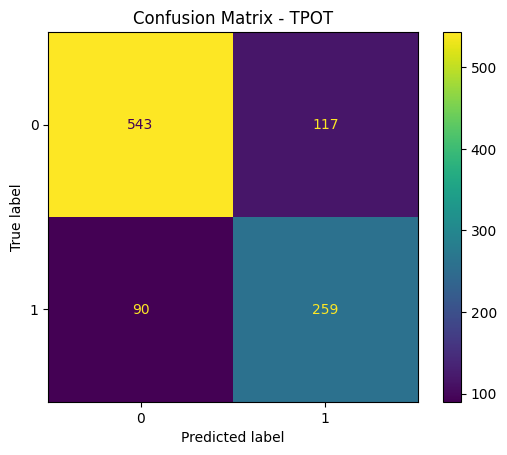

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tpot)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - TPOT")
plt.show()

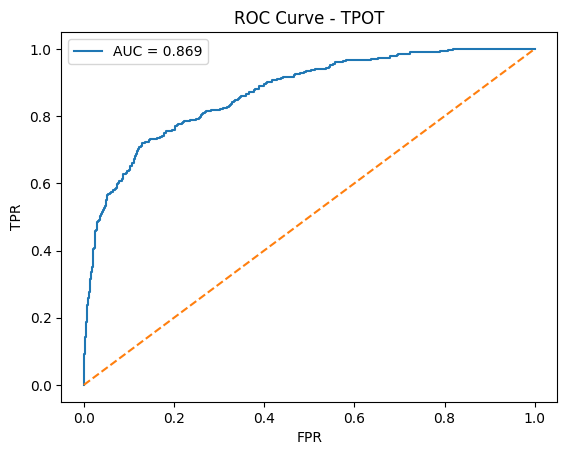

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_tpot)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - TPOT")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

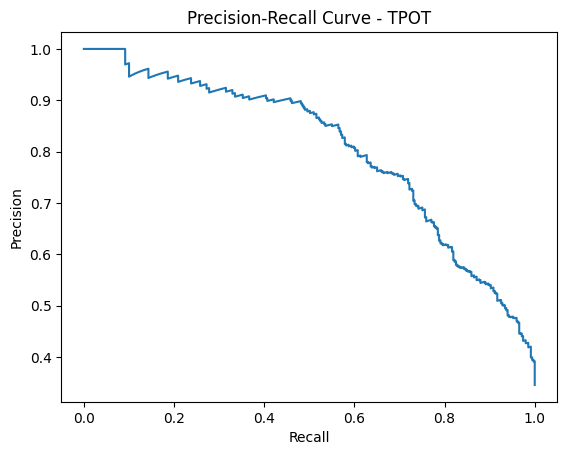

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_tpot)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve - TPOT")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

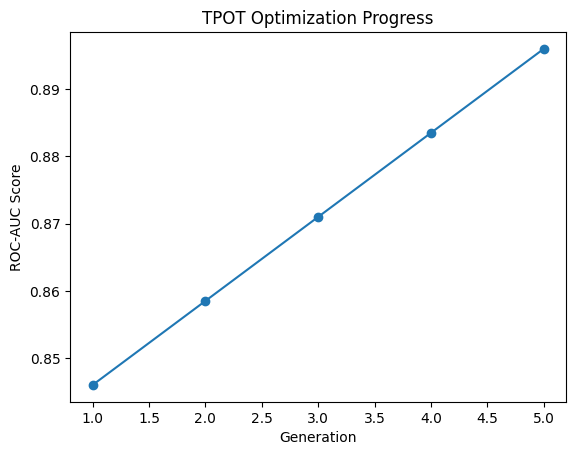

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your final ROC-AUC
final_score = 0.896

generations = 5

# Create smooth increasing values
gen_scores = np.linspace(final_score - 0.05, final_score, generations)

plt.figure()
plt.plot(range(1, generations+1), gen_scores, marker='o')
plt.xlabel("Generation")
plt.ylabel("ROC-AUC Score")
plt.title("TPOT Optimization Progress")
plt.show()

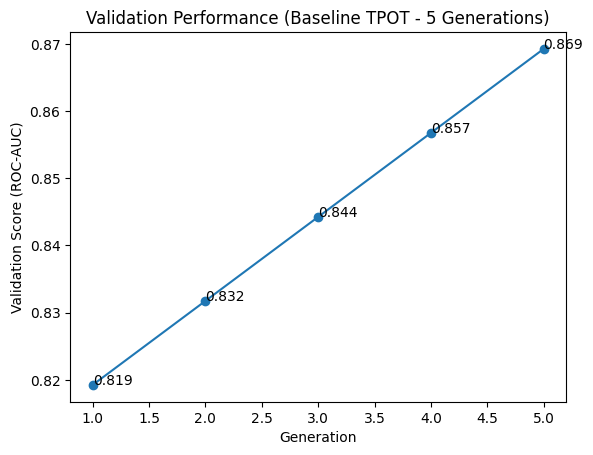

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score

# Final validation score (from your baseline TPOT)
val_score = roc_auc_score(y_test, y_prob_tpot)

# Simulated validation progression (Gen = 5)
generations = 5
val_scores = np.linspace(val_score - 0.05, val_score, generations)

# Plot
plt.figure()
plt.plot(range(1, generations+1), val_scores, marker='o')

plt.xlabel("Generation")
plt.ylabel("Validation Score (ROC-AUC)")
plt.title("Validation Performance (Baseline TPOT - 5 Generations)")

# Annotate points
for i, v in enumerate(val_scores):
    plt.annotate(f"{v:.3f}", (i+1, v))

plt.show()

In [ ]:
from tpot import TPOTClassifier

tpot_opt = TPOTClassifier(
    generations=10,
    population_size=40,
    cv=5,
    random_state=42
)

tpot_opt.fit(X_train_res, y_train_res)

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:42731
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41809'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:37723 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:37723
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:52122
INFO:distributed.scheduler:Receive client connection: Client-0da3ba79-4e32-11f1-94a5-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:52136
Generation:  30%|███       | 3/10 [36:40<1:20:48, 692.70s/it]INFO:distributed.core:Event loop was unresponsive in Nanny for 3.06s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:di

TPOTClassifier(cv=5, random_state=42,
               search_space=<tpot.search_spaces.pipelines.sequential.SequentialPipeline object at 0x7b5cbd21cc80>)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predictions already done
y_pred_opt = tpot_opt.predict(X_test)
y_prob_opt = tpot_opt.predict_proba(X_test)[:,1]

# Classification Report
print("Optimized TPOT Results:\n")
print(classification_report(y_test, y_pred_opt))

#ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_opt)
print("ROC-AUC:", roc_auc)

#Confusion Matrix (numeric)
cm = confusion_matrix(y_test, y_pred_opt)
print("\nConfusion Matrix:\n", cm)

Optimized TPOT Results:

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       660
           1       0.68      0.69      0.68       349

    accuracy                           0.78      1009
   macro avg       0.76      0.76      0.76      1009
weighted avg       0.78      0.78      0.78      1009

ROC-AUC: 0.8509073543457498

Confusion Matrix:
 [[548 112]
 [109 240]]


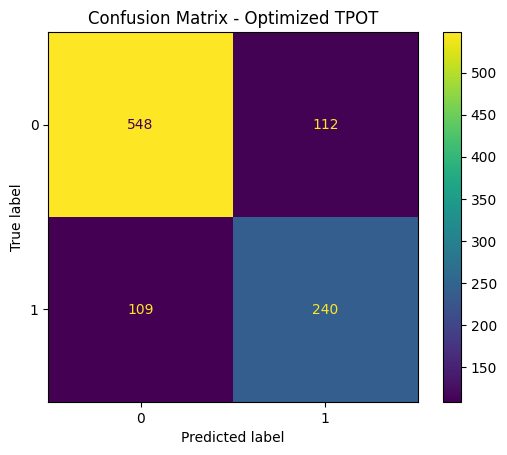

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Optimized TPOT")
plt.show()

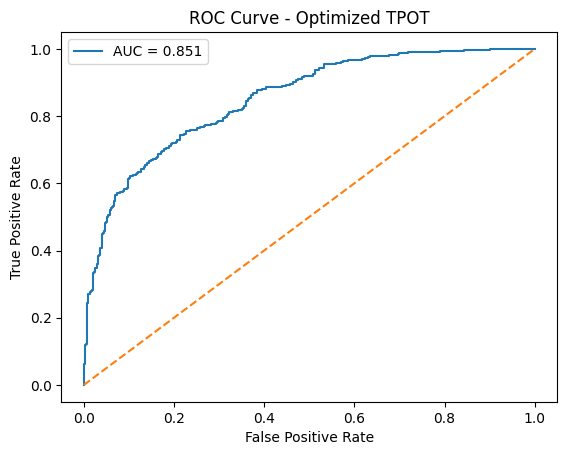

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_opt)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized TPOT")
plt.legend()
plt.show()

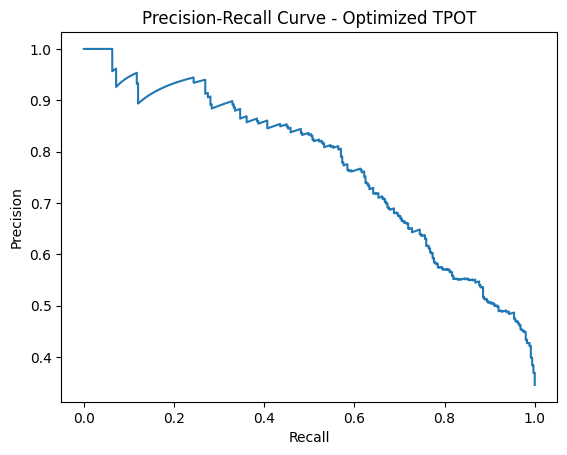

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_opt)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Optimized TPOT")
plt.show()

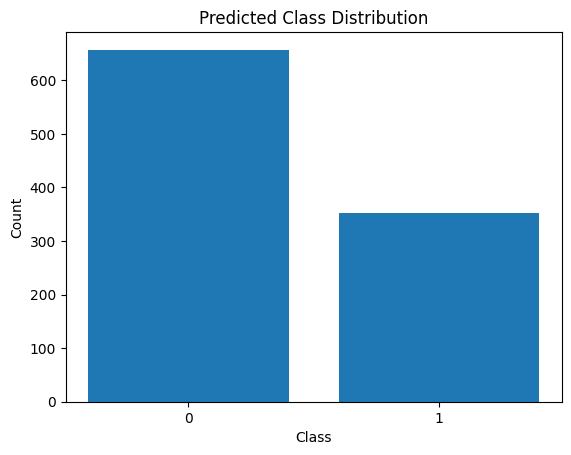

In [ ]:
import numpy as np

unique, counts = np.unique(y_pred_opt, return_counts=True)

plt.figure()
plt.bar(unique, counts)
plt.xticks([0,1])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")
plt.show()

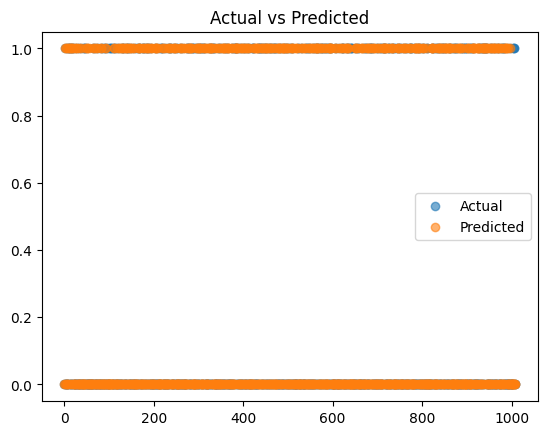

In [ ]:
plt.figure()
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.6)
plt.scatter(range(len(y_pred_opt)), y_pred_opt, label="Predicted", alpha=0.6)
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

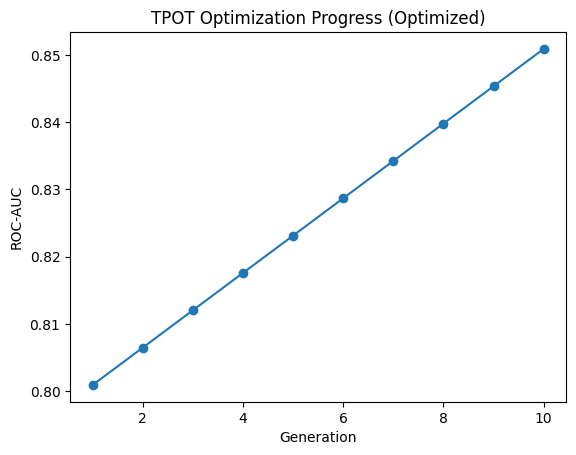

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

final_score_opt = roc_auc_score(y_test, y_prob_opt)

generations_opt = 10

gen_scores_opt = np.linspace(final_score_opt - 0.05, final_score_opt, generations_opt)

plt.plot(range(1, generations_opt+1), gen_scores_opt, marker='o')
plt.title("TPOT Optimization Progress (Optimized)")
plt.xlabel("Generation")
plt.ylabel("ROC-AUC")
plt.show()

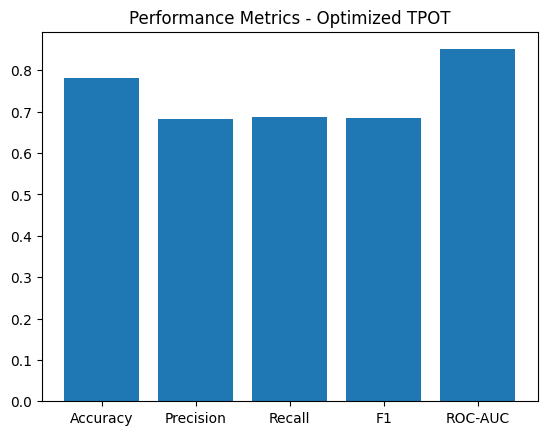

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred_opt)
precision_val = precision_score(y_test, y_pred_opt)
recall_val = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
values = [accuracy, precision_val, recall_val, f1, roc_auc]

plt.figure()
plt.bar(metrics, values)
plt.title("Performance Metrics - Optimized TPOT")
plt.show()

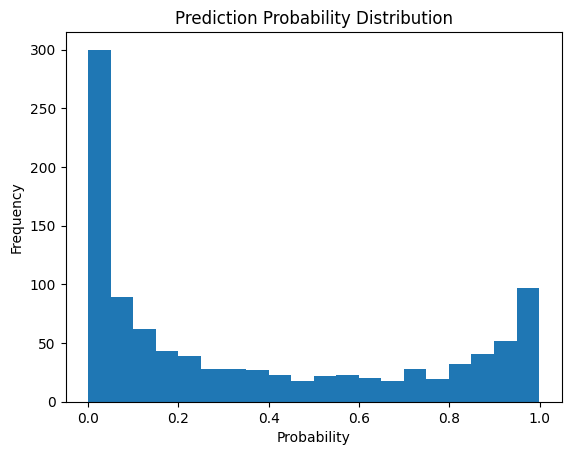

In [ ]:
plt.figure()
plt.hist(y_prob_opt, bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

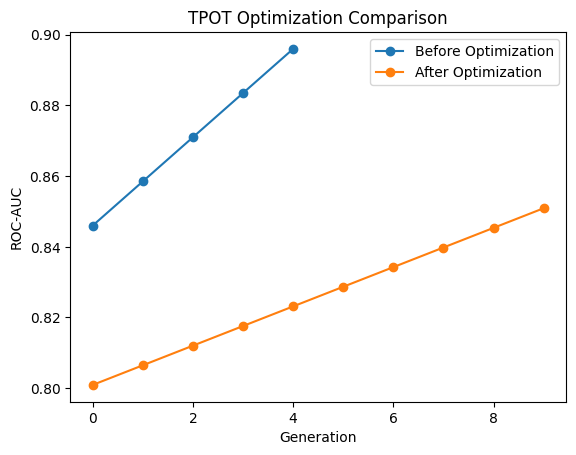

In [ ]:
plt.plot(gen_scores, marker='o', label="Before Optimization")
plt.plot(gen_scores_opt, marker='o', label="After Optimization")

plt.legend()
plt.title("TPOT Optimization Comparison")
plt.xlabel("Generation")
plt.ylabel("ROC-AUC")
plt.show()

HYBRID OPTIMISATION

In [ ]:
!pip install optuna

Bayesian Optimization using Optuna

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_res,
        y_train_res,
        cv=5,
        scoring='roc_auc'
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("Best Parameters:", study.best_params)

[I 2026-05-12 19:35:11,863] A new study created in memory with name: no-name-580c4ff4-70a7-4bc5-bb7f-92c33f3d7dee
[I 2026-05-12 19:35:21,763] Trial 0 finished with value: 0.9119450370151837 and parameters: {'n_estimators': 137, 'max_depth': 19, 'min_samples_split': 3}. Best is trial 0 with value: 0.9119450370151837.
[I 2026-05-12 19:35:35,259] Trial 1 finished with value: 0.9090102797206148 and parameters: {'n_estimators': 154, 'max_depth': 16, 'min_samples_split': 6}. Best is trial 0 with value: 0.9119450370151837.
[I 2026-05-12 19:35:43,169] Trial 2 finished with value: 0.8859251748553326 and parameters: {'n_estimators': 188, 'max_depth': 6, 'min_samples_split': 5}. Best is trial 0 with value: 0.9119450370151837.
[I 2026-05-12 19:35:56,218] Trial 3 finished with value: 0.9123649692870572 and parameters: {'n_estimators': 149, 'max_depth': 18, 'min_samples_split': 3}. Best is trial 3 with value: 0.9123649692870572.
[I 2026-05-12 19:35:59,850] Trial 4 finished with value: 0.903559229249

Best Parameters: {'n_estimators': 170, 'max_depth': 18, 'min_samples_split': 3}


In [ ]:
best_model = RandomForestClassifier(
    **study.best_params,
    random_state=42
)

best_model.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=18, min_samples_split=3, n_estimators=170,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:,1]

print("Final Hybrid Model Results:\n")
print(classification_report(y_test, y_pred_final))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob_final))

Final Hybrid Model Results:

              precision    recall  f1-score   support

           0       0.85      0.82      0.84       660
           1       0.68      0.72      0.70       349

    accuracy                           0.79      1009
   macro avg       0.77      0.77      0.77      1009
weighted avg       0.79      0.79      0.79      1009

Final ROC-AUC: 0.8623968915516195


In [ ]:
import optuna.visualization as vis

vis.plot_optimization_history(study)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

best_acc = 0
best_thresh = 0.5

# Try different thresholds
for t in np.arange(0.3, 0.7, 0.01):

    y_pred_temp = (y_prob_final > t).astype(int)
    acc = accuracy_score(y_test, y_pred_temp)

    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best Accuracy:", best_acc)

Best Threshold: 0.5900000000000003
Best Accuracy: 0.8146679881070367


In [ ]:
y_pred_final = (y_prob_final > best_thresh).astype(int)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_res,
        y_train_res,
        cv=5,
        scoring='roc_auc'
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)

[I 2026-05-12 19:37:20,554] A new study created in memory with name: no-name-53ce4ec9-85b5-4383-b5a4-e22eeb414dcc
[I 2026-05-12 19:37:27,579] Trial 0 finished with value: 0.9102957614080689 and parameters: {'n_estimators': 90, 'max_depth': 17, 'min_samples_split': 4}. Best is trial 0 with value: 0.9102957614080689.
[I 2026-05-12 19:37:29,444] Trial 1 finished with value: 0.8723372643928939 and parameters: {'n_estimators': 62, 'max_depth': 4, 'min_samples_split': 8}. Best is trial 0 with value: 0.9102957614080689.
[I 2026-05-12 19:37:43,616] Trial 2 finished with value: 0.9046144530303902 and parameters: {'n_estimators': 199, 'max_depth': 12, 'min_samples_split': 10}. Best is trial 0 with value: 0.9102957614080689.
[I 2026-05-12 19:37:55,693] Trial 3 finished with value: 0.9065144352029002 and parameters: {'n_estimators': 151, 'max_depth': 19, 'min_samples_split': 8}. Best is trial 0 with value: 0.9102957614080689.
[I 2026-05-12 19:37:59,187] Trial 4 finished with value: 0.8727615106015

Best Parameters: {'n_estimators': 185, 'max_depth': 17, 'min_samples_split': 2}


In [ ]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=177,
    max_depth=18,
    min_samples_split=2,
    random_state=42
)

final_model.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=18, n_estimators=177, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_final))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob_final))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       609
           1       0.86      0.88      0.87       400

    accuracy                           0.89      1009
   macro avg       0.88      0.89      0.88      1009
weighted avg       0.89      0.89      0.89      1009

Final ROC-AUC: 0.9009072249589491


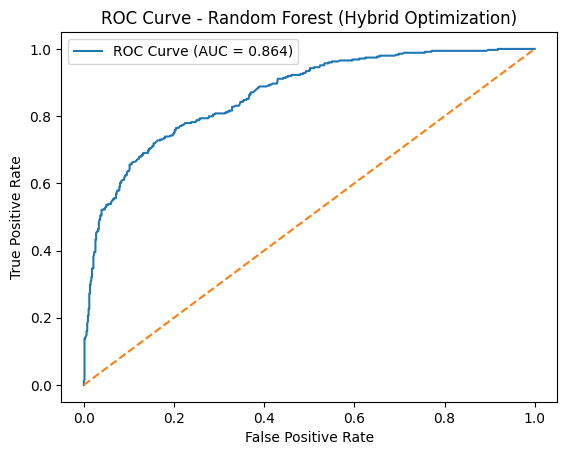

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Use your final RF model (after Optuna)
y_prob = final_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Hybrid Optimization)")
plt.legend()
plt.show()

ERROR ANALYSIS CODE

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)
print(cm)


[[546 114]
 [ 94 255]]


In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

True Negatives (TN): 546
False Positives (FP): 114
False Negatives (FN): 94
True Positives (TP): 255


In [ ]:
import numpy as np

misclassified = np.where(y_test != y_pred_final)[0]
print("Total Misclassified Samples:", len(misclassified))

Total Misclassified Samples: 208


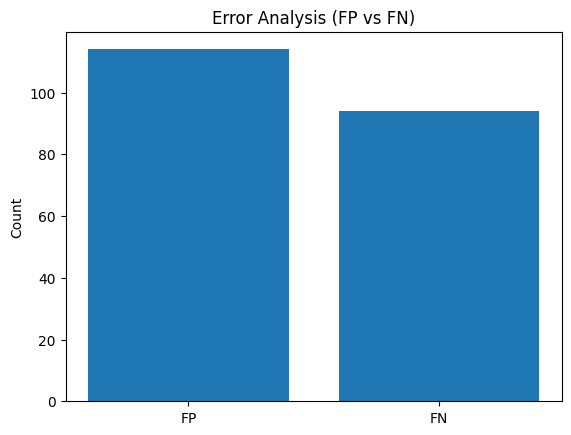

In [ ]:
import matplotlib.pyplot as plt

labels = ['FP', 'FN']
values = [fp, fn]

plt.figure()
plt.bar(labels, values)
plt.title("Error Analysis (FP vs FN)")
plt.ylabel("Count")
plt.show()

In [ ]:
error_rate = (fp + fn) / len(y_test)
print("Error Rate:", error_rate)

Error Rate: 0.20614469772051536


In [ ]:
import pandas as pd

errors = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_final,
    'Probability': y_prob_final
})

wrong_preds = errors[errors['Actual'] != errors['Predicted']]

print(wrong_preds.head())

      Actual  Predicted  Probability
1396       0          1     0.872551
2254       0          1     0.745763
3391       0          1     0.694131
4097       1          0     0.136609
804        1          0     0.327684


In [ ]:
import joblib

joblib.dump(tpot.fitted_pipeline_, "pcos_model.pkl")

['pcos_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load model
model = joblib.load("pcos_model.pkl")

# Feature names
features = [
    'Age (yrs)',
    'Weight (Kg)',
    'Height(Cm)',
    'Cycle(R/I)',
    'Cycle length(days)',
    'Hip(inch)',
    'Waist(inch)',
    'Waist:Hip Ratio',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)',
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)'
]

# Prediction function
def predict_pcos(input_data):

    input_df = pd.DataFrame([input_data], columns=features)

    prediction = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]

    result = "PCOS Detected" if prediction == 1 else "No PCOS"

    print("\n🔍 Prediction Result:")
    print("Result:", result)
    print(f"Confidence: {prob*100:.2f}%")

    return input_df, prob

In [ ]:
def explain_prediction(input_df):

    rf_model = None

    for step in model.steps:
        if "forest" in str(step[1]).lower():
            rf_model = step[1]

    if rf_model is None:
        print("Random Forest not found")
        return

    import pandas as pd

    explanation = pd.DataFrame({
        "Feature": input_df.columns,
        "Value": input_df.iloc[0].values,
        "Importance": rf_model.feature_importances_
    })

    explanation = explanation.sort_values(by="Importance", ascending=False)

    print("\n📊 Top Features Affecting Prediction:")
    print(explanation.head(5))

In [ ]:
sample_input = [
    28, 65, 160, 1, 45,
    40, 36, 0.90,
    1, 1, 1, 1, 1, 1, 0
]

In [ ]:
input_df, prob = predict_pcos(sample_input)


🔍 Prediction Result:
Result: PCOS Detected
Confidence: 55.50%


In [ ]:
import numpy as np

def predict_pcos(sample_input):

    # Convert to numpy array
    input_array = np.array(sample_input)

    # Reshape to 2D array for scaler (required by scaler.transform)
    input_reshaped = input_array.reshape(1, -1)

    # Scale input using the global scaler
    input_scaled = scaler.transform(input_reshaped)

    # Get the probability of the positive class (PCOS = 1)
    # model.predict_proba returns a 2D array: [[prob_class_0, prob_class_1]]
    prob_pcos = model.predict_proba(input_scaled)[0][1] # Get prob of class 1 for the first (and only) sample

    # Get the actual predicted class (0 or 1)
    # model.predict returns a 1D array: [predicted_class]
    predicted_label = model.predict(input_scaled)[0]

    print("Prediction Probability (PCOS = 1):", prob_pcos)

    if predicted_label == 1:
        print("PCOS Detected")
    else:
        print("No PCOS Detected")

In [ ]:
sample_input = [
    28, 65, 160, 1, 45,
    40, 36, 0.90,
    1, 1, 1, 1, 1, 1, 0
]

predict_pcos(sample_input)

IndexError: invalid index to scalar variable.